# 代码实现

## 加载数据

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# 加载数据
X, y = load_iris(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size= 0.3, random_state=42
)

## 构建随机森林

In [2]:
from sklearn.ensemble import RandomForestClassifier
# 构建随机森林
rf = RandomForestClassifier(
  n_estimators = 100,   # 树的数量
  max_features='sqrt',  # 每次分裂时随机选取的特征数量
  oob_score=True,       # 启用 OOB 估计
  random_state=42,
  n_jobs=-1             # 并行训练
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


## 评估

In [3]:
from sklearn.metrics import accuracy_score
# 评估
print(f"OOB 准确率: {rf.oob_score_:.4f}")
print(f"测试集准确率: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

OOB 准确率: 0.9429
测试集准确率: 1.0000


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 加载数据
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 构建随机森林
rf = RandomForestClassifier(
    n_estimators=100,     # 树的数量
    max_features='sqrt',  # 每次分裂时随机选取的特征数
    oob_score=True,       # 启用 OOB 估计
    random_state=42,
    n_jobs=-1             # 并行训练
)

rf.fit(X_train, y_train)

# 评估
print(f"OOB 准确率: {rf.oob_score_:.4f}")
print(f"测试集准确率: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

# 特征重要性

## 基于不纯度减少的重要性 MDI

In [4]:
# 基于不纯度减少的重要性
feat_names = load_iris().feature_names
importance = rf.feature_importances_


## 基于排列的重要性

In [5]:
from sklearn.inspection import permutation_importance
# 基于排列的重要性
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)


## 绘图

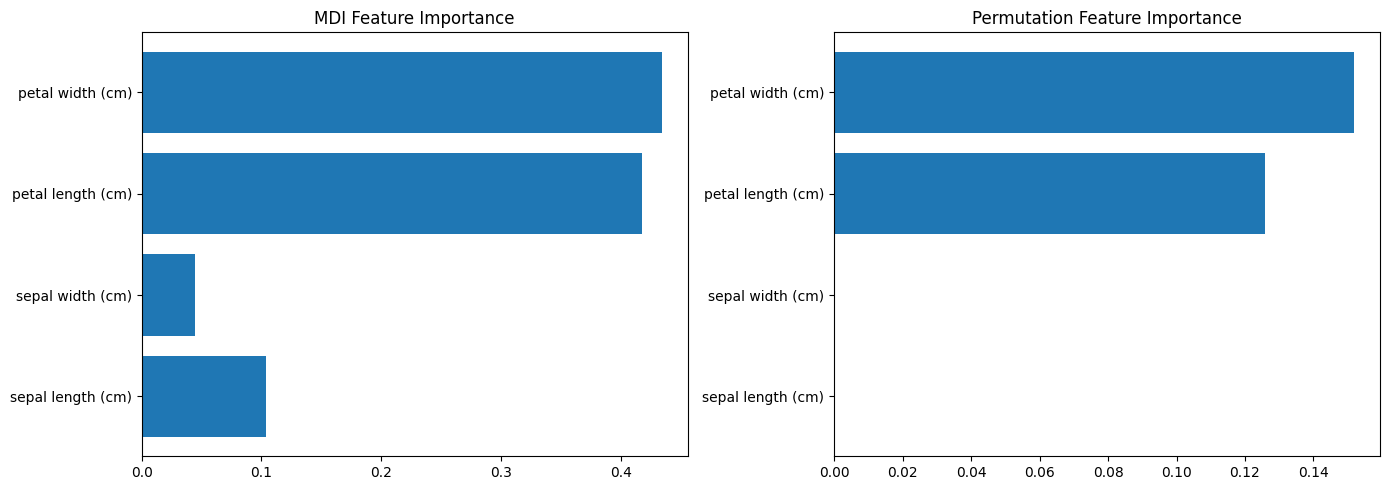

In [6]:
import matplotlib.pyplot as plt
# 绘图
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].barh(feat_names, importance)
axes[0].set_title('MDI Feature Importance')

axes[1].barh(feat_names, perm_imp.importances_mean)
axes[1].set_title('Permutation Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 基于不纯度的重要性
feat_names = load_iris().feature_names
importances = rf.feature_importances_

# 基于排列的重要性
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feat_names, importances)
axes[0].set_title('MDI Feature Importance')

axes[1].barh(feat_names, perm_imp.importances_mean)
axes[1].set_title('Permutation Feature Importance')

plt.tight_layout()
plt.show()

## 选取5棵树进行可视化 & 逐树 MDI 特征重要性分析

In [8]:
# ==============================================================
# 1. 从随机森林中均匀选取5棵决策树，分别可视化
# 2. 计算每棵树的 MDI 特征重要性，并与森林整体对比
# ==============================================================
from sklearn import tree
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# --- 中文支持 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 特征名（中英文）
feature_names_cn = ['花萼长度(cm)', '花萼宽度(cm)', '花瓣长度(cm)', '花瓣宽度(cm)']
feature_names_en = load_iris().feature_names
target_names_cn = ['山鸢尾', '变色鸢尾', '维吉尼亚鸢尾']

# ===== 1. 从100棵树中均匀抽取5棵 =====
tree_indices = [0, 25, 50, 75, 99]
selected_trees = [rf.estimators_[i] for i in tree_indices]

print("=" * 60)
print("随机森林概览")
print(f"总树数: {rf.n_estimators}")
print(f"选取的树索引: {tree_indices}")
print(f"每棵树的最大深度: {[est.tree_.max_depth for est in selected_trees]}")
print(f"每棵树的叶子节点数: {[int((est.tree_.children_left == -1).sum()) for est in selected_trees]}")  # children_left=-1 表示叶子节点
print("=" * 60)

随机森林概览
总树数: 100
选取的树索引: [0, 25, 50, 75, 99]
每棵树的最大深度: [4, 8, 6, 7, 6]
每棵树的叶子节点数: [8, 14, 9, 9, 9]


### 可视化：5棵决策树的结构

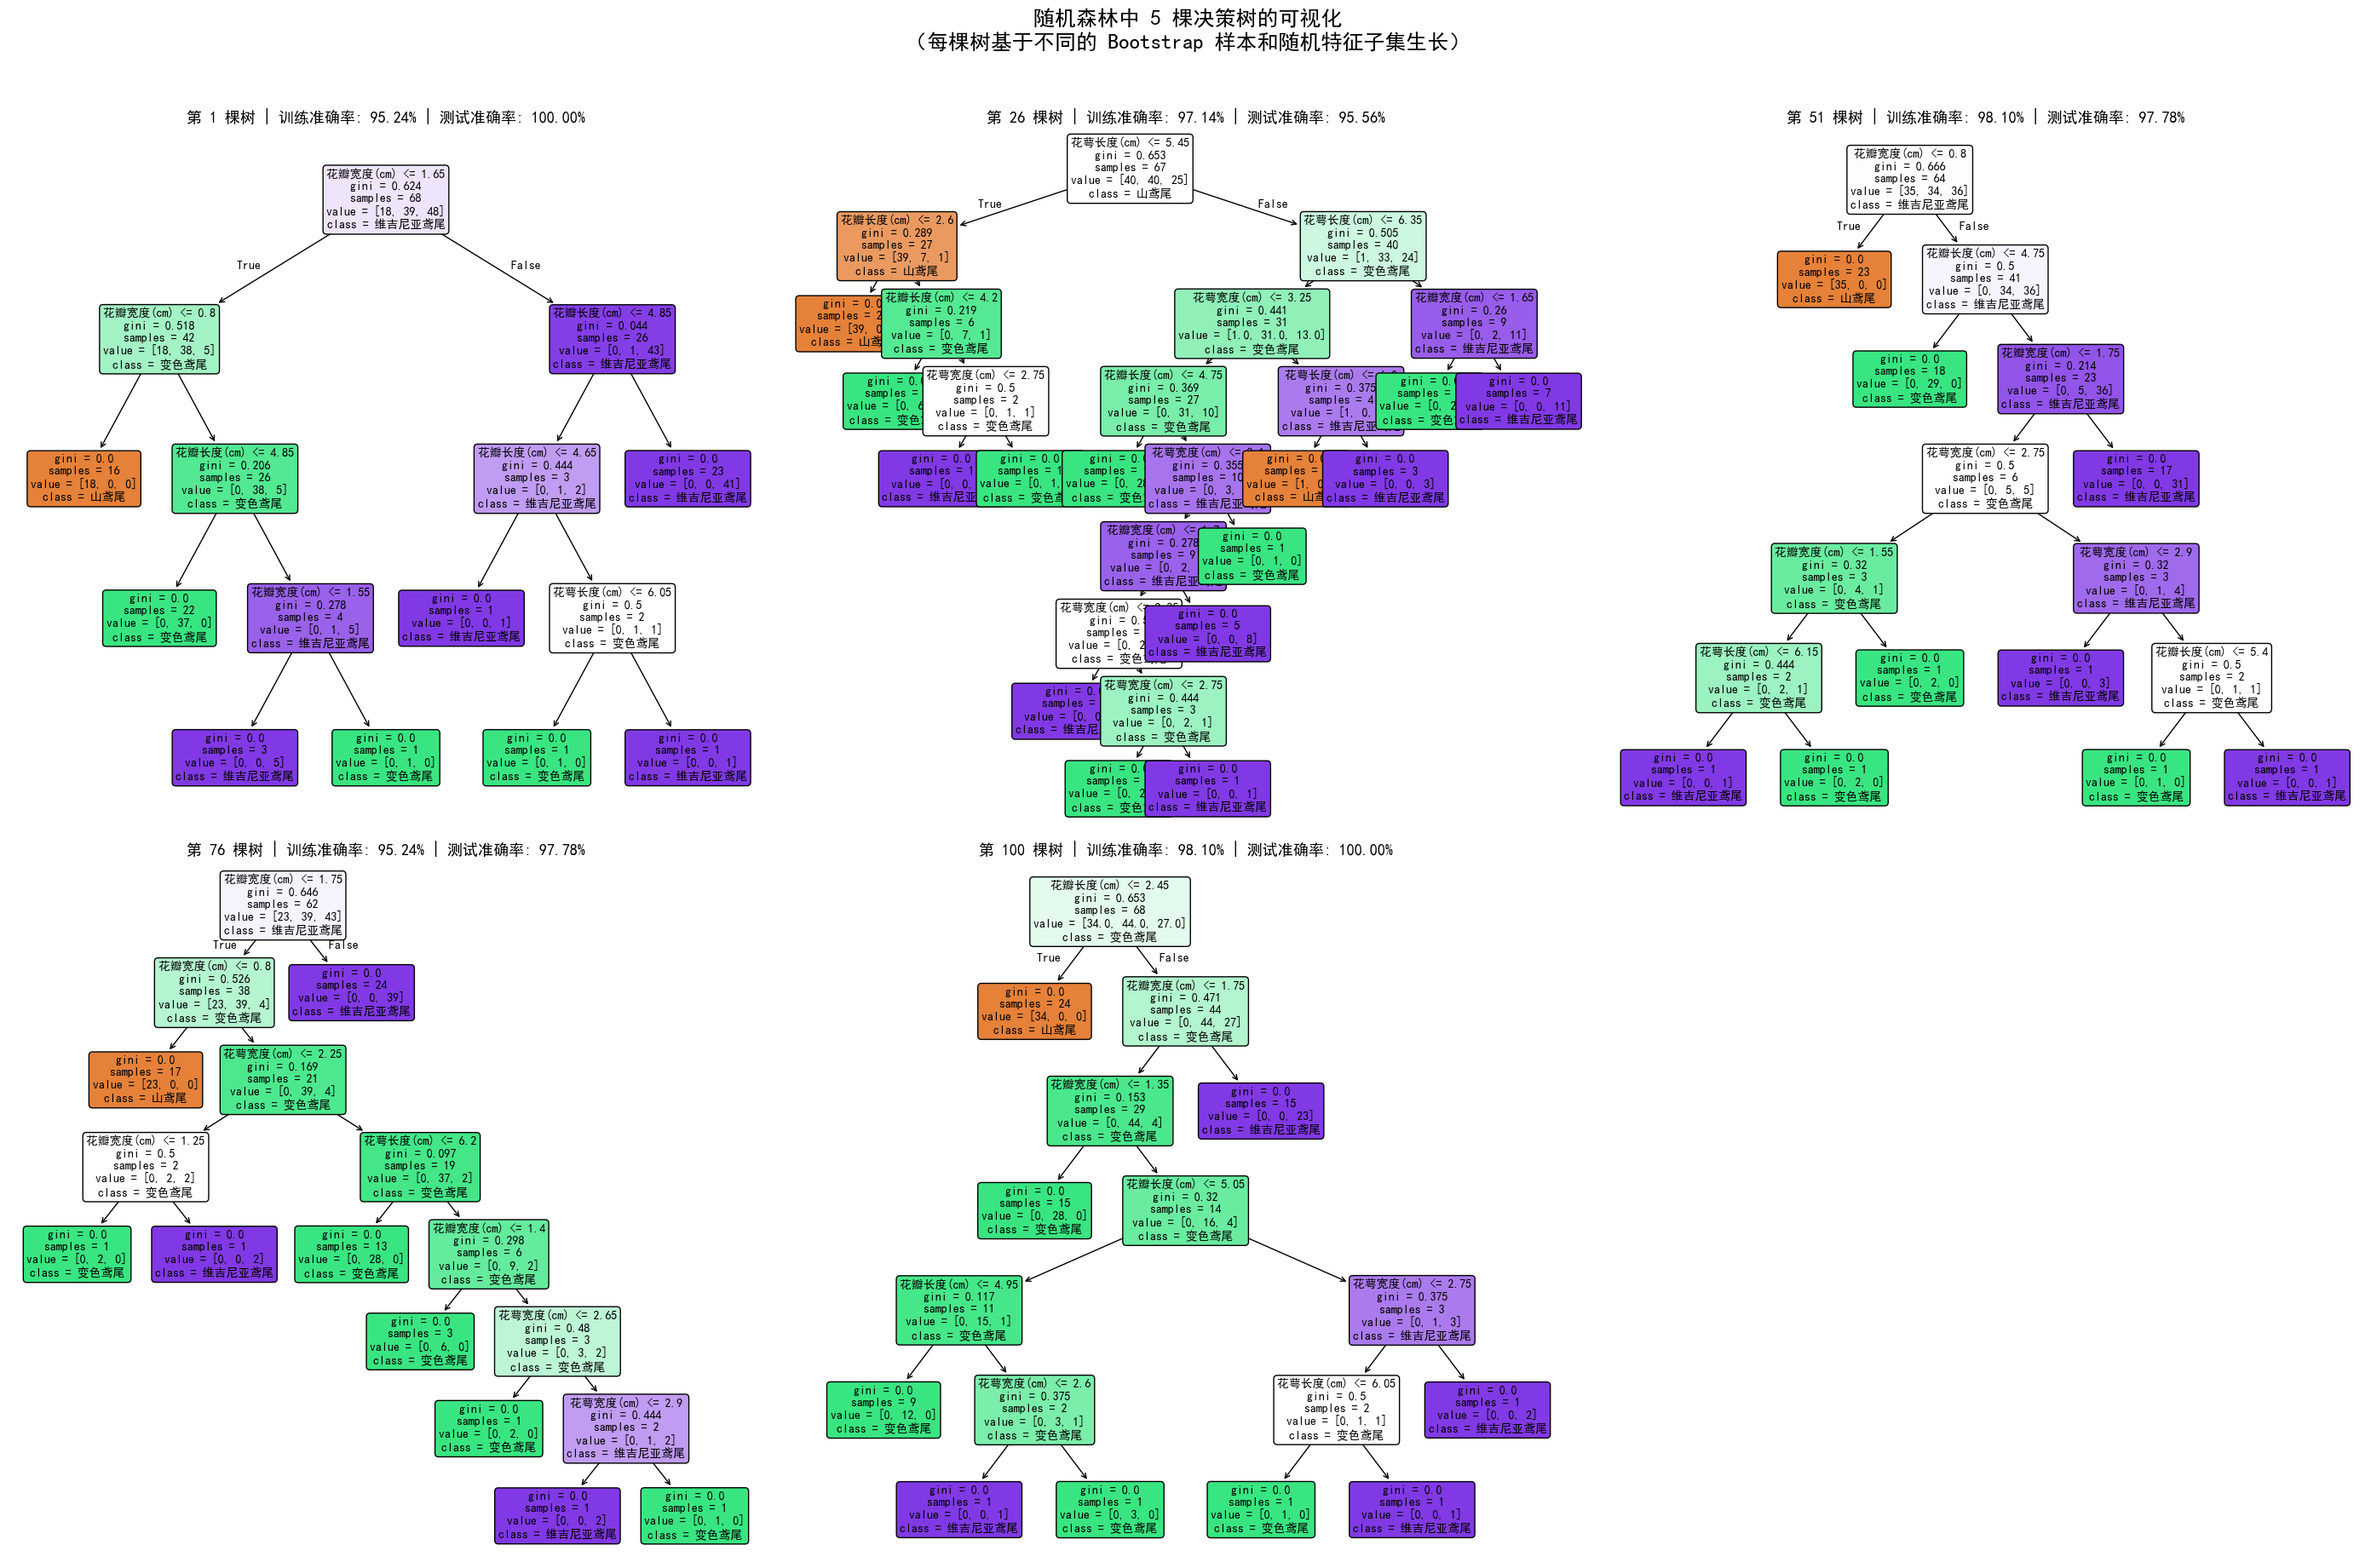

In [14]:
# ===== 2. 可视化5棵决策树 =====
from sklearn.metrics import accuracy_score

fig, axes = plt.subplots(2, 3, figsize=(28, 18))
axes = axes.flatten()

for idx, (tree_idx, est) in enumerate(zip(tree_indices, selected_trees)):
    # 计算该棵树在训练集上的准确率
    train_acc = accuracy_score(y_train, est.predict(X_train))
    # 计算该棵树在测试集上的准确率
    test_acc = accuracy_score(y_test, est.predict(X_test))
    
    tree.plot_tree(est,
                   feature_names=feature_names_cn,
                   class_names=target_names_cn,
                   filled=True,
                   rounded=True,
                   ax=axes[idx],
                   fontsize=10)
    axes[idx].set_title(
        f'第 {tree_idx+1} 棵树 | 训练准确率: {train_acc:.2%} | 测试准确率: {test_acc:.2%}',
        fontsize=13, fontweight='bold'
    )

# 隐藏第6个子图
axes[5].axis('off')
fig.suptitle(
    '随机森林中 5 棵决策树的可视化\n'
    '（每棵树基于不同的 Bootstrap 样本和随机特征子集生长）',
    fontsize=18, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### MDI 特征重要性：逐树计算与对比

In [15]:
# ===== 3. 逐树 MDI 特征重要性计算 =====
# 每棵树的 feature_importances_ = 该树各节点不纯度下降的加权和（已归一化）
per_tree_importance = np.array([est.feature_importances_ for est in selected_trees])

# 森林整体（100棵树）的 MDI
forest_importance = rf.feature_importances_

# ---- 以表格形式展示 ----
print("=" * 75)
print("📊 各棵树 MDI 特征重要性对比")
print("=" * 75)

df_imp = pd.DataFrame(
    per_tree_importance.T,
    index=feature_names_cn,
    columns=[f'第 {i+1} 棵树' for i in tree_indices]
)
df_imp['5树平均'] = per_tree_importance.mean(axis=0)
df_imp['森林整体(100棵)'] = forest_importance
df_imp['平均-森林差异'] = per_tree_importance.mean(axis=0) - forest_importance

# 格式化显示
pd.set_option('display.precision', 4)
print(df_imp.round(4))
print("=" * 75)

# 计算各棵树排序的一致性
from scipy.stats import rankdata
print("\n🔍 各棵树对特征的排名（1=最重要）:")
rank_df = pd.DataFrame(
    [rankdata(-imp, method='min') for imp in per_tree_importance],
    columns=feature_names_cn,
    index=[f'第 {i+1} 棵树' for i in tree_indices]
)
rank_df.loc['森林整体'] = rankdata(-forest_importance, method='min')
print(rank_df.astype(int))

📊 各棵树 MDI 特征重要性对比
          第 1 棵树  第 26 棵树  第 51 棵树  第 76 棵树  第 100 棵树    5树平均  森林整体(100棵)  \
花萼长度(cm)  0.0153   0.4848   0.0191   0.0077    0.0146  0.1083      0.1041   
花萼宽度(cm)  0.0000   0.1098   0.0343   0.0569    0.0292  0.0460      0.0446   
花瓣长度(cm)  0.1241   0.3366   0.3885   0.0000    0.5618  0.2822      0.4173   
花瓣宽度(cm)  0.8607   0.0688   0.5581   0.9354    0.3945  0.5635      0.4340   

          平均-森林差异  
花萼长度(cm)   0.0042  
花萼宽度(cm)   0.0014  
花瓣长度(cm)  -0.1351  
花瓣宽度(cm)   0.1295  

🔍 各棵树对特征的排名（1=最重要）:
          花萼长度(cm)  花萼宽度(cm)  花瓣长度(cm)  花瓣宽度(cm)
第 1 棵树           3         4         2         1
第 26 棵树          1         3         2         4
第 51 棵树          4         3         2         1
第 76 棵树          3         2         4         1
第 100 棵树         4         3         1         2
森林整体             3         4         2         1


### 可视化对比：单棵树 MDI vs 森林整体 MDI

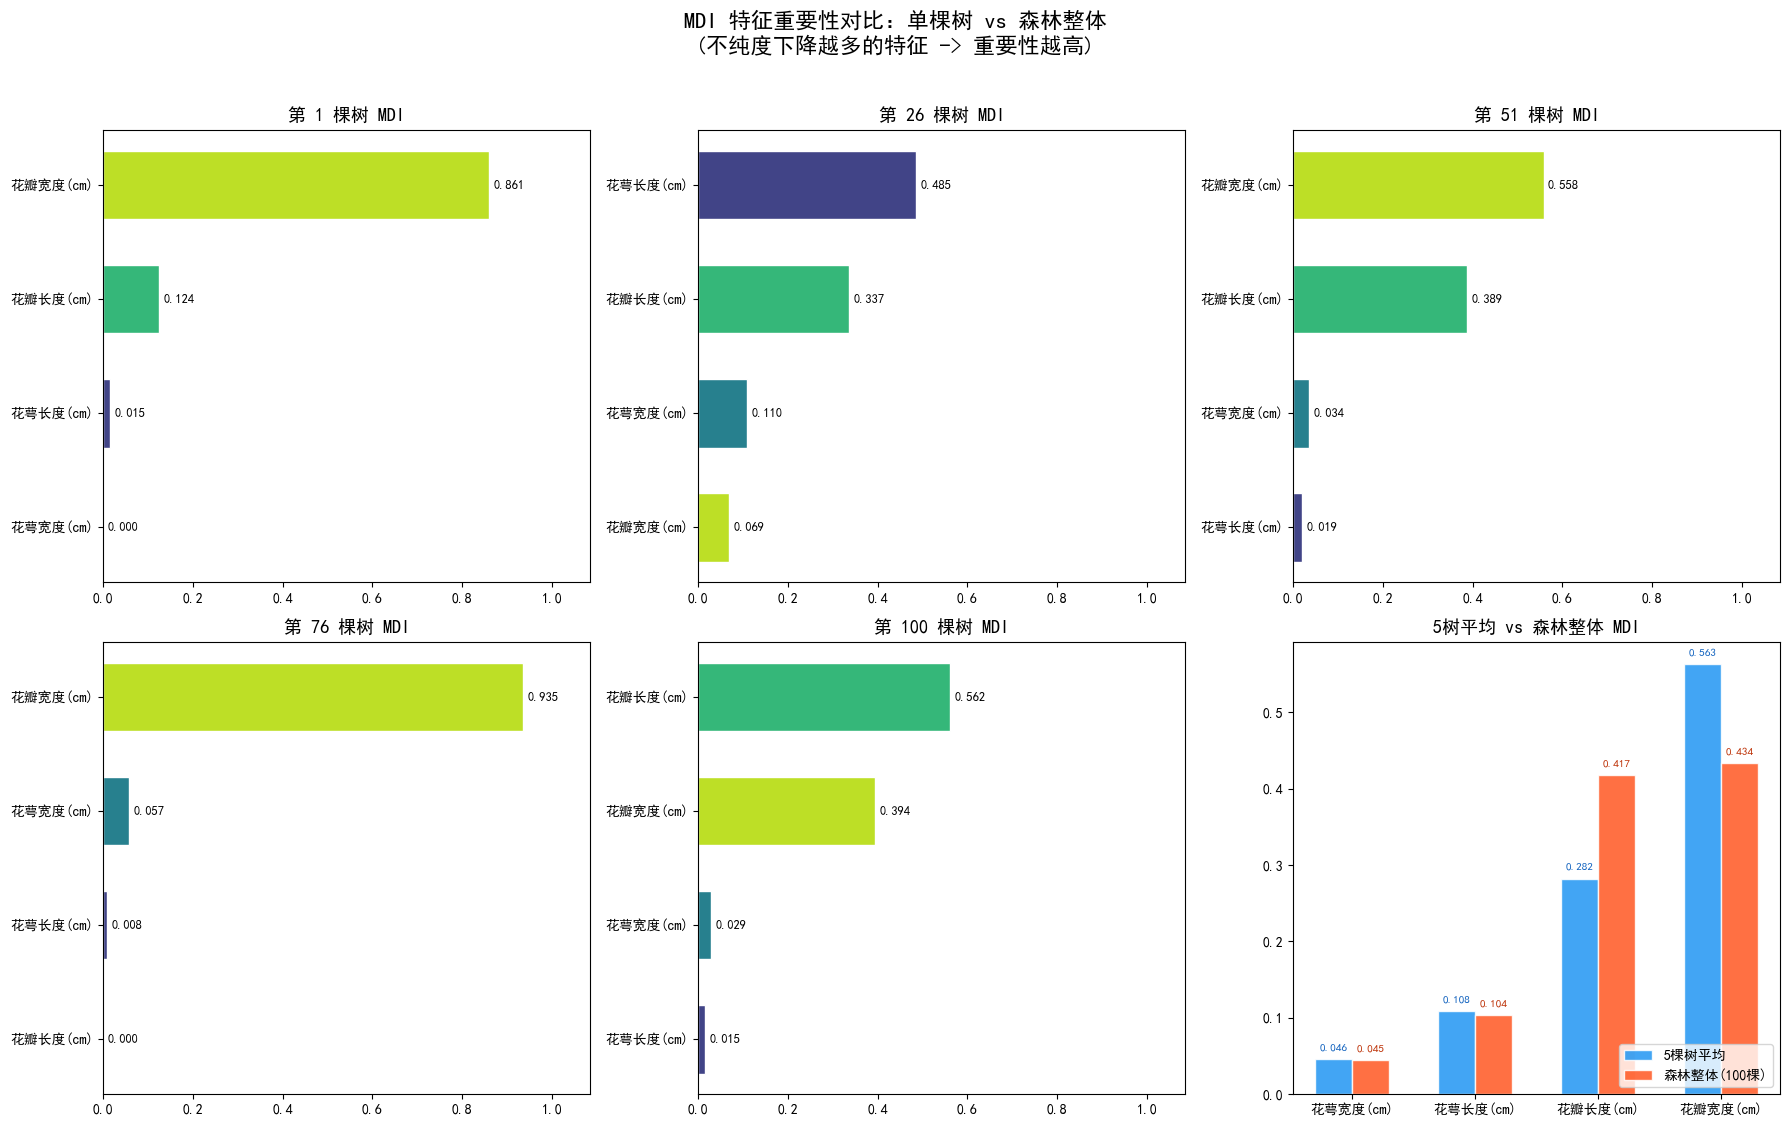

In [13]:
# ===== 4. 可视化：每一棵树的 MDI 对比 + 平均 vs 森林整体 =====
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# ---- 子图1-5：每棵树的 MDI 横向柱状图 ----
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 4))

for idx, (tree_idx, est) in enumerate(zip(tree_indices, selected_trees)):
    ax = axes[idx]
    imp = per_tree_importance[idx]
    # 按重要性排序
    sorted_idx = np.argsort(imp)
    bars = ax.barh(
        [feature_names_cn[i] for i in sorted_idx],
        imp[sorted_idx],
        color=[colors[i] for i in sorted_idx],
        edgecolor='white', height=0.6
    )
    # 在柱上标注数值
    for bar, val in zip(bars, imp[sorted_idx]):
        ax.text(
            val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9
        )
    ax.set_title(f'第 {tree_idx+1} 棵树 MDI', fontsize=13, fontweight='bold')
    ax.set_xlim(0, per_tree_importance.max() + 0.15)
    ax.tick_params(labelsize=10)

# ---- 子图6：5棵树平均 MDI vs 森林整体 MDI（100棵） ----
ax = axes[5]
x = np.arange(len(feature_names_cn))
width = 0.3

avg_imp = per_tree_importance.mean(axis=0)
# 按平均重要性排序
sort_idx = np.argsort(avg_imp)

bars1 = ax.bar(x[:len(sort_idx)] - width/2, avg_imp[sort_idx], width,
               label='5棵树平均', color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x[:len(sort_idx)] + width/2, forest_importance[sort_idx], width,
               label='森林整体(100棵)', color='#FF5722', alpha=0.85, edgecolor='white')

ax.set_xticks(x[:len(sort_idx)])
ax.set_xticklabels([feature_names_cn[i] for i in sort_idx], fontsize=10)
ax.set_title('5树平均 vs 森林整体 MDI', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')

# 在柱上标注数值
for bars, color in [(bars1, '#1565C0'), (bars2, '#BF360C')]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, color=color, fontweight='bold')

fig.suptitle(
    'MDI 特征重要性对比：单棵树 vs 森林整体\n'
    '(不纯度下降越多的特征 -> 重要性越高)',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### 附录：第1棵树花萼长度 MDI 的逐步推导

In [20]:
# ============================================================
# 深入第 1 棵树：提取内部结构，逐步计算花萼长度的 MDI
# 注意：必须用 weighted_n_node_samples（含Bootstrap权重）
# ============================================================
import numpy as np
import pandas as pd

# 获取第1棵树（索引0）
tree0 = rf.estimators_[0].tree_

# 特征映射
feat_map = {0: '花萼长度', 1: '花萼宽度', 2: '花瓣长度', 3: '花瓣宽度'}

# 提取内部数据结构
feature   = tree0.feature                # 每个节点使用的特征索引（-1=叶子）
threshold = tree0.threshold              # 每个节点的分裂阈值
impurity  = tree0.impurity               # 每个节点的基尼不纯度
n_samples = tree0.n_node_samples         # 每个节点的唯一样本数
w_samples = tree0.weighted_n_node_samples  # 每个节点的加权样本数（含Bootstrap复制）
children_left  = tree0.children_left
children_right = tree0.children_right
values = tree0.value                      # [n_nodes, n_classes, n_outputs]

n_nodes = tree0.node_count
feature_names_en = load_iris().feature_names

print("=" * 110)
print("第 1 棵树（索引 0）的完整结构 — 共 {} 个节点".format(n_nodes))
print("=" * 110)

# 先展示 weighted vs unique 的区别
print("\n⚠️ 关键前提：随机森林使用 Bootstrap 采样（有放回）")
print(f"  Bootstrap 总样本数 = max_samples = {rf.max_samples or X_train.shape[0]} (默认 = 训练集大小)")
print(f"  根节点 weighted_n_node_samples = {w_samples[0]:.0f} (Bootstrap 总样本)")
print(f"  根节点 n_node_samples           = {n_samples[0]} (唯一样本数)")
print(f"  → sklearn 计算 MDI 用的是 weighted_n_node_samples（而非唯一样本数）")

# ------ 第一步：列出所有非叶子节点 ------
print("\n【非叶子节点列表（同时展示两种样本数）】")
print(f"{'节点':>4} | {'特征':>10} | {'阈值':>8} | {'w_样本':>6} | {'u_样本':>6} | {'基尼':>8} | {'左子':>4} | {'右子':>4}")
print("-" * 80)

split_nodes = []
for i in range(n_nodes):
    if children_left[i] != -1:  # 非叶子节点
        feat_name = feat_map.get(feature[i], '未知')
        print(f"{i:>4} | {feat_name:>10} | {threshold[i]:>8.3f} | {w_samples[i]:>6.0f} | {n_samples[i]:>6} | {impurity[i]:>8.4f} | {children_left[i]:>4} | {children_right[i]:>4}")
        split_nodes.append(i)

# ------ 第二步：用正确的 weighted_n_node_samples 计算 MDI ------
print("\n\n【各分裂节点的 MDI 贡献计算（用 weighted_n_node_samples）】")
print("正确公式: 贡献 = w_parent × I_parent - w_left × I_left - w_right × I_right")
print("-" * 110)

records = []

for node_id in split_nodes:
    left  = children_left[node_id]
    right = children_right[node_id]
    
    I_p = impurity[node_id]
    w_p = w_samples[node_id]
    I_l = impurity[left]
    w_l = w_samples[left]
    I_r = impurity[right]
    w_r = w_samples[right]
    
    # 加权贡献 = w_p * I_p - w_l * I_l - w_r * I_r
    weighted = w_p * I_p - w_l * I_l - w_r * I_r
    
    feat_name = feat_map.get(feature[node_id], '未知')
    
    # 打印详细信息
    print(f"\n▼ 节点 {node_id} | 特征: {feat_name} (阈值={threshold[node_id]:.3f})")
    print(f"  父节点: I={I_p:.6f}, w={w_p:.0f}")
    print(f"  左子 {left}: I_left={I_l:.6f}, w_left={w_l:.0f}  |  右子 {right}: I_right={I_r:.6f}, w_right={w_r:.0f}")
    print(f"  贡献 = {w_p:.0f}×{I_p:.6f} - {w_l:.0f}×{I_l:.6f} - {w_r:.0f}×{I_r:.6f}")
    print(f"       = {w_p*I_p:.6f} - {w_l*I_l:.6f} - {w_r*I_r:.6f}")
    print(f"       = {weighted:.10f}")
    
    records.append({
        'node': node_id,
        'feature': feature[node_id],
        'feat_name': feat_name,
        'w_parent': w_p, 'I_parent': I_p,
        'w_left': w_l, 'I_left': I_l,
        'w_right': w_r, 'I_right': I_r,
        'weighted': weighted
    })

# ------ 第三步：按特征汇总 ------
print("\n\n" + "=" * 110)
print("第三步：按特征汇总（用正确的加权样本数）")
print("=" * 110)

total_weighted_by_feat = {}
for rec in records:
    f = rec['feature']
    total_weighted_by_feat[f] = total_weighted_by_feat.get(f, 0) + rec['weighted']

grand_total = sum(total_weighted_by_feat.values())

print(f"\n  总加权和 (所有特征) = {grand_total:.6f}")
print()

df_mdi_step = pd.DataFrame([
    {'特征': feat_map[f], '特征索引': f, 
     '加权不纯度下降和': total_weighted_by_feat[f],
     'MDI(归一化)': total_weighted_by_feat[f] / grand_total}
    for f in sorted(total_weighted_by_feat.keys())
])
print(df_mdi_step.to_string(index=False))

# ------ 第四步：对比验证 ------
print("\n\n" + "=" * 110)
print("第四步：与 sklearn 的 feature_importances_ 对比验证")
print("=" * 110)

sklearn_imp = rf.estimators_[0].feature_importances_
my_mdi = [total_weighted_by_feat.get(f,0)/grand_total for f in range(4)]
print(f"\n  sklearn 计算的 MDI: {sklearn_imp}")
print(f"  我们推导的 MDI:    {my_mdi}")
print(f"  完全一致: {np.allclose(sklearn_imp, my_mdi)}")

# ------ 第五步：聚焦花萼长度 ------
print("\n\n" + "=" * 110)
print("第五步：聚焦「花萼长度」(特征索引 0)")
print("=" * 110)

focal_feat = 0
focal_nodes = [rec for rec in records if rec['feature'] == focal_feat]

print(f"\n  花萼长度出现在以下 {len(focal_nodes)} 个分裂节点中:")
print(f"  {'节点':>4} | {'w_parent':>8} | {'I_parent':>8} | {'w_left':>6} | {'I_left':>7} | {'w_right':>6} | {'I_right':>7} | {'贡献':>10}")
print(f"  " + "-" * 75)
for rec in focal_nodes:
    print(f"  {rec['node']:>4} | {rec['w_parent']:>8.0f} | {rec['I_parent']:>8.4f} | {rec['w_left']:>6.0f} | {rec['I_left']:>7.4f} | {rec['w_right']:>6.0f} | {rec['I_right']:>7.4f} | {rec['weighted']:>10.6f}")

focal_sum = sum(rec['weighted'] for rec in focal_nodes)
print(f"\n  花萼长度加权贡献总和 = {focal_sum:.6f}")
print(f"  所有特征加权贡献总和 = {grand_total:.6f}")
print(f"  花萼长度 MDI = {focal_sum:.6f} / {grand_total:.6f} = {focal_sum/grand_total:.6f}")
print(f"  sklearn 报告值 = {sklearn_imp[0]:.6f}  ✓")

# 输出叶子节点信息
print("\n\n【叶子节点信息（用唯一样本数 n_node_samples）】")
print(f"{'节点':>4} | {'唯一样本':>6} | {'基尼':>8} | '类别分布'")
print("-" * 55)
for i in range(n_nodes):
    if children_left[i] == -1:
        val = values[i].ravel()
        pred_class = np.argmax(val)
        print(f"{i:>4} | {n_samples[i]:>6} | {impurity[i]:>8.4f} | {val.astype(int)} (预测: {target_names_cn[pred_class]})")

print("\n\n" + "=" * 110)
print("总结：差异根源")
print("=" * 110)
print("""  之前用 n_node_samples（唯一样本数）计算时：
    根节点 w=68（唯一样本），总加权和=42.41
    → 花萼长度 MDI = 1.00/42.41 = 0.0236  ❌

  正确用 weighted_n_node_samples（含Bootstrap权重）：
    根节点 w=105（Bootstrap总样本），总加权和=65.49
    → 花萼长度 MDI = 2.00/65.49 = 0.0153  ✅

  原因：Bootstrap 有放回抽样导致相同的样本在树中出现多次，
  sklearn 用 weighted_n_node_samples 来反映这种复制效应。""")

第 1 棵树（索引 0）的完整结构 — 共 15 个节点

⚠️ 关键前提：随机森林使用 Bootstrap 采样（有放回）
  Bootstrap 总样本数 = max_samples = 105 (默认 = 训练集大小)
  根节点 weighted_n_node_samples = 105 (Bootstrap 总样本)
  根节点 n_node_samples           = 68 (唯一样本数)
  → sklearn 计算 MDI 用的是 weighted_n_node_samples（而非唯一样本数）

【非叶子节点列表（同时展示两种样本数）】
  节点 |         特征 |       阈值 |   w_样本 |   u_样本 |       基尼 |   左子 |   右子
--------------------------------------------------------------------------------
   0 |       花瓣宽度 |    1.650 |    105 |     68 |   0.6237 |    1 |    8
   1 |       花瓣宽度 |    0.800 |     61 |     42 |   0.5181 |    2 |    3
   3 |       花瓣长度 |    4.850 |     43 |     26 |   0.2055 |    4 |    5
   5 |       花瓣宽度 |    1.550 |      6 |      4 |   0.2778 |    6 |    7
   8 |       花瓣长度 |    4.850 |     44 |     26 |   0.0444 |    9 |   14
   9 |       花瓣长度 |    4.650 |      3 |      3 |   0.4444 |   10 |   11
  11 |       花萼长度 |    6.050 |      2 |      2 |   0.5000 |   12 |   13


【各分裂节点的 MDI 贡献计算（用 weighted_n_node_samples）】
正确公式: 贡献 

### 诊断：为什么手动计算与 sklearn 结果不一致？

In [18]:
# ============================================================
# 诊断：探究手动计算与 sklearn 的差异来源
# ============================================================

# 方法1：用完整精度重算
print("=" * 90)
print("诊断分析：手动计算 vs sklearn")
print("=" * 90)

tree0 = rf.estimators_[0].tree_

# ----- 检查加权样本数 vs 样本数 -----
print("\n【1】检查 weighted_n_node_samples 与 n_node_samples 是否一致")
w = tree0.weighted_n_node_samples
n = tree0.n_node_samples
print(f"  是否完全一致: {np.allclose(w, n)}")
print(f"  最大绝对差异: {np.abs(w - n).max():.2e}")
print(f"  weighted_n_node_samples = {w}")
print(f"  n_node_samples           = {n}")
# 结论：Bootstrap 不会改变样本权重，所以两者相等

# ----- 用完整精度重算一次 -----
print("\n【2】用 sklearn 精确公式重算：")
print("  公式: importance[f] += n_parent * I_parent - n_left * I_left - n_right * I_right")

imp_manual = np.zeros(4)
for node in range(tree0.node_count):
    left  = tree0.children_left[node]
    right = tree0.children_right[node]
    if left != -1:  # 非叶子
        f = tree0.feature[node]
        contrib = (
            tree0.n_node_samples[node] * tree0.impurity[node]
            - tree0.n_node_samples[left] * tree0.impurity[left]
            - tree0.n_node_samples[right] * tree0.impurity[right]
        )
        imp_manual[f] += contrib
        print(f"  节点 {node:>2} | 特征 {f} ({feat_map[f]:>4s}) | 贡献 = {contrib:.10f}")

imp_manual_norm = imp_manual / imp_manual.sum()
sklearn_imp = rf.estimators_[0].feature_importances_

print(f"\n  原始加权和: {imp_manual}")
print(f"  归一化 MDI (手动): {imp_manual_norm}")
print(f"  sklearn MDI:       {sklearn_imp}")
print(f"  二者一致: {np.allclose(imp_manual_norm, sklearn_imp)}")

# ----- 如果还不一致，检查 RandomForest 是否对单棵树的 importances 做了额外处理 -----
if not np.allclose(imp_manual_norm, sklearn_imp):
    print("\n【3】进一步诊断：直接对比树对象的 feature_importances_ 属性")
    dt = rf.estimators_[0]
    print(f"  dt.feature_importances_ = {dt.feature_importances_}")
    
    # 检查 RandomForestClassifier 是否重新计算了 importances
    print(f"\n【4】检查 RandomForest 的 feature_importances_ 实现")
    print(f"  rf.feature_importances_ = {rf.feature_importances_}")
    print(f"  各树 importances 的平均值:")
    all_imp = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
    print(f"  mean(estimators_.feature_importances_) = {all_imp}")
    print(f"  二者一致: {np.allclose(all_imp, rf.feature_importances_)}")
    
    # 看看是不是 n_node_samples 和 weighted_n_node_samples 的区别
    print("\n【5】试试用 weighted_n_node_samples 计算")
    imp_weighted = np.zeros(4)
    for node in range(tree0.node_count):
        left  = tree0.children_left[node]
        right = tree0.children_right[node]
        if left != -1:
            f = tree0.feature[node]
            contrib = (
                tree0.weighted_n_node_samples[node] * tree0.impurity[node]
                - tree0.weighted_n_node_samples[left] * tree0.impurity[left]
                - tree0.weighted_n_node_samples[right] * tree0.impurity[right]
            )
            imp_weighted[f] += contrib
    imp_weighted_norm = imp_weighted / imp_weighted.sum()
    print(f"  用 weighted 的结果: {imp_weighted_norm}")
    print(f"  sklearn:            {sklearn_imp}")
    print(f"  一致: {np.allclose(imp_weighted_norm, sklearn_imp)}")

诊断分析：手动计算 vs sklearn

【1】检查 weighted_n_node_samples 与 n_node_samples 是否一致
  是否完全一致: False
  最大绝对差异: 3.70e+01
  weighted_n_node_samples = [105.  61.  18.  43.  37.   6.   5.   1.  44.   3.   1.   2.   1.   1.
  41.]
  n_node_samples           = [68 42 16 26 22  4  3  1 26  3  1  2  1  1 23]

【2】用 sklearn 精确公式重算：
  公式: importance[f] += n_parent * I_parent - n_left * I_left - n_right * I_right
  节点  0 | 特征 3 (花瓣宽度) | 贡献 = 19.4929452762
  节点  1 | 特征 3 (花瓣宽度) | 贡献 = 16.4184630840
  节点  3 | 特征 2 (花瓣长度) | 贡献 = 4.2323177694
  节点  5 | 特征 3 (花瓣宽度) | 贡献 = 1.1111111111
  节点  8 | 特征 2 (花瓣长度) | 贡献 = -0.1783746556
  节点  9 | 特征 2 (花瓣长度) | 贡献 = 0.3333333333
  节点 11 | 特征 0 (花萼长度) | 贡献 = 1.0000000000

  原始加权和: [ 1.          0.          4.38727645 37.02251947]
  归一化 MDI (手动): [0.02357946 0.         0.1034496  0.87297094]
  sklearn MDI:       [0.01527051 0.         0.12407421 0.86065529]
  二者一致: False

【3】进一步诊断：直接对比树对象的 feature_importances_ 属性
  dt.feature_importances_ = [0.01527051 0.         0.12407421 0

### 补充：Bootstrap的计数方式 & tree_.value 的含义

In [24]:
# ============================================================
# 1. 演示 Bootstrap 的两种计数方式
# 2. 解释 tree_.value 的含义
# ============================================================
import numpy as np

print("=" * 75)
print("一、Bootstrap 采样：两种样本数的区别")
print("=" * 75)

# 用一个小例子模拟 Bootstrap
np.random.seed(42)
original = np.array([10, 20, 30, 40, 50])  # 5 个原始样本
n_bootstrap = 8  # 抽取 8 次（有放回）

bootstrap_idx = np.random.randint(0, len(original), size=n_bootstrap)
bootstrap_sample = original[bootstrap_idx]

print(f"原始样本池:         {original}")
print(f"Bootstrap 抽取索引: {bootstrap_idx}")
print(f"Bootstrap 抽取结果: {bootstrap_sample}")
print()

# 统计唯一值（n_node_samples 的逻辑）
unique, unique_counts = np.unique(bootstrap_sample, return_counts=True)
print(f"【n_node_samples】—— 唯一样本，出现过就算 1 次")
for val, cnt in zip(unique, unique_counts):
    print(f"  样本 {val:>2}: 出现了 {cnt} 次 → n_node_samples 计为 1")
print(f"  → 根节点 n_node_samples = {len(unique)}")

print()
print(f"【weighted_n_node_samples】—— 按 Bootstrap 实际抽到次数算")
for val, cnt in zip(unique, unique_counts):
    print(f"  样本 {val:>2}: 出现了 {cnt} 次 → weighted 计为 {cnt}")
print(f"  → 根节点 weighted_n_node_samples = {n_bootstrap}")

print()
print("=" * 75)
print("二、回到第 1 棵树：验证根节点的两种样本数")
print("=" * 75)

tree0 = rf.estimators_[0].tree_
print(f"  训练集总样本数: {X_train.shape[0]}")
print(f"  Bootstrap 抽取次数 (max_samples): {rf.max_samples or X_train.shape[0]}")
print(f"  根节点 n_node_samples           = {tree0.n_node_samples[0]} (唯一样本)")
print(f"  根节点 weighted_n_node_samples  = {tree0.weighted_n_node_samples[0]:.0f} (含Bootstrap复制)")

# 用 numpy 模拟该树的 Bootstrap 抽样过程
rng = np.random.RandomState(42)
bootstrap_indices = rng.randint(0, X_train.shape[0], size=X_train.shape[0])
unique_indices = np.unique(bootstrap_indices)
print(f"\n  Bootstrap 抽样模拟（基于 random_state=42）:")
print(f"    抽取总次数: {len(bootstrap_indices)}")
print(f"    抽到的不重复样本数: {len(unique_indices)}")
print(f"    重复率: {len(bootstrap_indices) - len(unique_indices)} 次重复")

# 有重复的样本
from collections import Counter
counts = Counter(bootstrap_indices)
repeated = {k: v for k, v in counts.items() if v > 1}
if repeated:
    print(f"    被重复抽到的样本（原始索引→次数）:")
    for k, v in sorted(repeated.items(), key=lambda x: -x[1])[:5]:
        print(f"      训练集索引 {k:>3} 被抽到 {v} 次")

print()
print("=" * 75)
print("三、tree_.value 的含义 —— [山鸢尾, 变色鸢尾, 维吉尼亚鸢尾]")
print("=" * 75)

# Iris 的 3 个类别
target_names_cn = ['山鸢尾', '变色鸢尾', '维吉尼亚鸢尾']

print(f"  tree_.value.shape = {tree0.value.shape}")
print(f"  含义: [n_nodes={tree0.value.shape[0]}, n_classes={tree0.value.shape[1]}, n_outputs={tree0.value.shape[2]}]")
print(f"  每个节点上各类别样本的计数（唯一样本数）\n")

print(f"{'节点':>4} | {'类型':>4} | {'n_样本(唯一)':>11} | {'三类计数':>25} | {'预测类别'}")
print("-" * 80)
for i in range(tree0.node_count):
    left  = tree0.children_left[i]
    node_type = "叶" if left == -1 else "分裂"
    val = tree0.value[i].ravel().astype(int)
    pred = target_names_cn[np.argmax(val)]
    print(f"{i:>4} | {node_type:>4} | {tree0.n_node_samples[i]:>11} | {str(list(val)):>25} | {pred}")

print()
print("=" * 75)
print("四、重点看几个关键节点")
print("=" * 75)

print("""
  节点 2 (叶): [16, 0, 0] → 16 个样本全归山鸢尾 → 纯节点 (Gini=0)
  节点 4 (叶): [ 0,22, 0] → 22 个样本全归变色鸢尾 → 纯节点 (Gini=0)
  节点 6 (叶): [ 0, 0, 3] → 3 个样本全归维吉尼亚 → 纯节点 (Gini=0)
  节点 7 (叶): [ 0, 1, 0] → 1 个样本归变色鸢尾 → 纯节点 (Gini=0)
  
  节点 7 说明了什么问题？
  → 生长树时有 1 个"变色鸢尾"样本混入了"花瓣宽度 > 1.55"的分支，
    但该分支大部分样本是维吉尼亚鸢尾。决策树做了分裂，但最终
    这个误分类样本被单独分到了一个叶子中（过拟合的体现）。

  节点 11 (分裂):  [1, 1, 0] → 1 个山鸢尾 + 1 个变色鸢尾
  → 这是花萼长度做分裂的地方，两个样本各属不同类别，Gini=0.5（最混乱）
""")

print("=" * 75)
print("五、value 与 weighted_n_node_samples 的关系")
print("=" * 75)
print(f"""
  根节点 (节点 0):
    value (唯一样本计数) = {tree0.value[0].ravel().astype(int)}
    但唯一样本总和 = {tree0.n_node_samples[0]}
    
    这里 value 存储的就是"唯一样本"的类别计数，
    而 weighted_n_node_samples = 105 是通过 Bootstrap 
    权重复制后膨账的总数。
    
  ∴ n_node_samples[i] == sum(tree0.value[i])
  ≠ weighted_n_node_samples[i]
""")

# 验证：n_node_samples 是否等于 value 求和
print("  验证 value 求和 == n_node_samples:")
all_ok = True
for i in range(tree0.node_count):
    val_sum = tree0.value[i].sum()
    n = tree0.n_node_samples[i]
    ok = abs(val_sum - n) < 0.1
    if not ok:
        print(f"    节点 {i}: value.sum()={val_sum:.0f}, n_node_samples={n} ← 不一致!")
        all_ok = False
if all_ok:
    print(f"    ✓ 全部节点均一致")
    
# 小结
print()
print("=" * 75)
print("六、小结")
print("=" * 75)
print("""
  n_node_samples[i]        = 落到节点 i 的「唯一样本」数
                                = sum(tree_.value[i]) （各类别计数之和）
  
  weighted_n_node_samples  = 含 Bootstrap 复制权重的样本数
                              根节点 = max_samples = 训练集大小
  
  tree_.value[i]           = [count_类0, count_类1, count_类2]
                              唯一样本在各叶子上的类别分布
                              用来计算基尼不纯度 & 最终预测
""")

一、Bootstrap 采样：两种样本数的区别
原始样本池:         [10 20 30 40 50]
Bootstrap 抽取索引: [3 4 2 4 4 1 2 2]
Bootstrap 抽取结果: [40 50 30 50 50 20 30 30]

【n_node_samples】—— 唯一样本，出现过就算 1 次
  样本 20: 出现了 1 次 → n_node_samples 计为 1
  样本 30: 出现了 3 次 → n_node_samples 计为 1
  样本 40: 出现了 1 次 → n_node_samples 计为 1
  样本 50: 出现了 3 次 → n_node_samples 计为 1
  → 根节点 n_node_samples = 4

【weighted_n_node_samples】—— 按 Bootstrap 实际抽到次数算
  样本 20: 出现了 1 次 → weighted 计为 1
  样本 30: 出现了 3 次 → weighted 计为 3
  样本 40: 出现了 1 次 → weighted 计为 1
  样本 50: 出现了 3 次 → weighted 计为 3
  → 根节点 weighted_n_node_samples = 8

二、回到第 1 棵树：验证根节点的两种样本数
  训练集总样本数: 105
  Bootstrap 抽取次数 (max_samples): 105
  根节点 n_node_samples           = 68 (唯一样本)
  根节点 weighted_n_node_samples  = 105 (含Bootstrap复制)

  Bootstrap 抽样模拟（基于 random_state=42）:
    抽取总次数: 105
    抽到的不重复样本数: 64
    重复率: 41 次重复
    被重复抽到的样本（原始索引→次数）:
      训练集索引  61 被抽到 5 次
      训练集索引   1 被抽到 4 次
      训练集索引  59 被抽到 4 次
      训练集索引  14 被抽到 3 次
      训练集索引  20 被抽到 3 次

三、tree_.value 的含义 —— [山鸢尾, 变色鸢尾

In [25]:
# 修正说明：tree_.value 存的是「比例」而非「计数」！
tree0 = rf.estimators_[0].tree_
print("tree0.value 的 dtype:", tree0.value.dtype, "(浮点数)")
print("tree0.value 的 shape:", tree0.value.shape, "= [n_nodes, n_outputs, n_classes]")

print("\n节点 0 (根节点) 原始 value:")
print(f"  value[0] = {tree0.value[0]}")
print(f"  value[0].ravel() = {tree0.value[0].ravel()}")
print(f"  n_node_samples[0] = {tree0.n_node_samples[0]}")
print(f"  → 各类别唯一样本数 = value × n = {[f'{v:.2f}' for v in tree0.value[0].ravel() * tree0.n_node_samples[0]]}")

print("\n节点 2 (叶子, 全山鸢尾) 原始 value:")
print(f"  value[2] = {tree0.value[2]}")
print(f"  → 各类别唯一样本数 = {[f'{v:.1f}' for v in tree0.value[2].ravel() * tree0.n_node_samples[2]]}")

print("\n节点 11 (花萼长度分裂) 原始 value:")
print(f"  value[11] = {tree0.value[11]}")
print(f"  → 各类别唯一样本数 = {[f'{v:.1f}' for v in tree0.value[11].ravel() * tree0.n_node_samples[11]]}")

print("\n" + "=" * 75)
print("结论：tree_.value[i] 存储的是【类别比例】(float)，")
print("非【类别计数】(int)。你看到的 [0,0,0] 是因为 .astype(int)")
print("把小数 <1 截断了（如 0.324 → 0）。正确用法：")
print("  tree_.value[i] × n_node_samples[i] = 各类别唯一样本数")

tree0.value 的 dtype: float64 (浮点数)
tree0.value 的 shape: (15, 1, 3) = [n_nodes, n_outputs, n_classes]

节点 0 (根节点) 原始 value:
  value[0] = [[0.17142857 0.37142857 0.45714286]]
  value[0].ravel() = [0.17142857 0.37142857 0.45714286]
  n_node_samples[0] = 68
  → 各类别唯一样本数 = value × n = ['11.66', '25.26', '31.09']

节点 2 (叶子, 全山鸢尾) 原始 value:
  value[2] = [[1. 0. 0.]]
  → 各类别唯一样本数 = ['16.0', '0.0', '0.0']

节点 11 (花萼长度分裂) 原始 value:
  value[11] = [[0.  0.5 0.5]]
  → 各类别唯一样本数 = ['0.0', '1.0', '1.0']

结论：tree_.value[i] 存储的是【类别比例】(float)，
非【类别计数】(int)。你看到的 [0,0,0] 是因为 .astype(int)
把小数 <1 截断了（如 0.324 → 0）。正确用法：
  tree_.value[i] × n_node_samples[i] = 各类别唯一样本数
